In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import numpy as np

In [37]:
df = pd.read_csv("/Volumes/KINGSTON/code/phd/image-analysis/synapse-counting/output_data/results.csv")
df.columns

Index(['Unnamed: 0', 'img_filename', 'overlap_um2', 'overlap_um2_rot',
       'pearson_cor', 'pvalue', 'pearson_cor_rot', 'pvalue_rot',
       'overlap_coeff', 'overlap_coeff_rot', 'presynapse_threshold',
       'postsynapse_threshold', 'presynapse_image_mfi',
       'postsynapse_image_mfi', 'pre_puncta_density_per_100_um2',
       'post_puncta_density_per_100_um2', 'pre_staining_area_um2',
       'post_staining_area_um2', 'pre_mean_puncta_size_um2',
       'post_mean_puncta_size_um2', 'gRNA', 'hippocampal_layer'],
      dtype='object')

In [38]:
# adding a brain column to the dataframe
df['Brain'] = df['img_filename'].str.split('_').str[2]

In [39]:
def check_statistics(df, hippocampal_layer, metric, candidate_gRNA, control_gRNA = "LacZ-gRNA"):
    filtered_df_hip_layer = df[df["hippocampal_layer"].str.contains(hippocampal_layer)]
    ReplicateAverages = filtered_df_hip_layer.groupby(["gRNA","Brain"], as_index=False).agg({metric:"mean"})
    ReplicateAveragesPivot = ReplicateAverages.pivot_table(columns="gRNA", values=metric, index="Brain")
    statistic, pvalue = scipy.stats.ttest_rel(ReplicateAveragesPivot[control_gRNA], ReplicateAveragesPivot[candidate_gRNA])
    
    return filtered_df_hip_layer, ReplicateAveragesPivot, statistic, pvalue

In [40]:
_ , table, _ , p_value = check_statistics(df, hippocampal_layer = "CA3 SL", metric = "presynapse_image_mfi", candidate_gRNA = "VCAM1-gRNA")
p_value

0.011440825772768679

In [47]:
hippocampal_layers = ["CA1 SLM", "CA1 SR", "CA1 SO", "CA3 SO", "CA3 SL", "CA3 SR", "DG ML", "DG Hilus"]
metrics = ["overlap_um2", "pearson_cor", "overlap_coeff", "presynapse_image_mfi", "postsynapse_image_mfi", "pre_puncta_density_per_100_um2", "post_puncta_density_per_100_um2", "pre_staining_area_um2", "post_staining_area_um2", "pre_mean_puncta_size_um2", "post_mean_puncta_size_um2"]

statistics_results = []

for hippocampal_layer in hippocampal_layers:
    for metric in metrics:
        _ , table, _ , p_value = check_statistics(df, hippocampal_layer = hippocampal_layer, metric = metric, candidate_gRNA = "VCAM1-gRNA")
        statistics_results.append({"hippocampal_layer": hippocampal_layer, "metric": metric, "p_value": p_value})

df_statistics_results = pd.DataFrame(statistics_results)  # Create DataFrame from list
print(df_statistics_results)

   hippocampal_layer                           metric   p_value
0            CA1 SLM                      overlap_um2  0.357073
1            CA1 SLM                      pearson_cor  0.791739
2            CA1 SLM                    overlap_coeff  0.481896
3            CA1 SLM             presynapse_image_mfi  0.962370
4            CA1 SLM            postsynapse_image_mfi  0.897151
..               ...                              ...       ...
83          DG Hilus  post_puncta_density_per_100_um2  0.950039
84          DG Hilus            pre_staining_area_um2  0.665412
85          DG Hilus           post_staining_area_um2  0.915346
86          DG Hilus         pre_mean_puncta_size_um2  0.887264
87          DG Hilus        post_mean_puncta_size_um2  0.818562

[88 rows x 3 columns]


In [57]:
df_statistics_results['statistical significant?'] = np.where(df_statistics_results["p_value"] <= 0.05, 'Yes', 'No')
df_statistics_results

,hippocampal_layer,metric,p_value,statistical significant?
0,CA1 SLM,overlap_um2,0.357073,No
1,CA1 SLM,pearson_cor,0.791739,No
2,CA1 SLM,overlap_coeff,0.481896,No
3,CA1 SLM,presynapse_image_mfi,0.962370,No
4,CA1 SLM,postsynapse_image_mfi,0.897151,No
...,...,...,...,...
83,DG Hilus,post_puncta_density_per_100_um2,0.950039,No
84,DG Hilus,pre_staining_area_um2,0.665412,No
85,DG Hilus,post_staining_area_um2,0.915346,No
86,DG Hilus,pre_mean_puncta_size_um2,0.887264,No


In [58]:
p_value_threshold = 0.05  # Set your desired p-value threshold
filtered_df = df_statistics_results[df_statistics_results["p_value"] <= p_value_threshold]

# Print the filtered DataFrame
print(filtered_df)

   hippocampal_layer                     metric   p_value  \
25            CA1 SO       presynapse_image_mfi  0.036487   
33            CA3 SO                overlap_um2  0.026188   
35            CA3 SO              overlap_coeff  0.000415   
36            CA3 SO       presynapse_image_mfi  0.022510   
37            CA3 SO      postsynapse_image_mfi  0.023217   
41            CA3 SO     post_staining_area_um2  0.048587   
42            CA3 SO   pre_mean_puncta_size_um2  0.031116   
43            CA3 SO  post_mean_puncta_size_um2  0.026330   
47            CA3 SL       presynapse_image_mfi  0.011441   
58            CA3 SR       presynapse_image_mfi  0.000840   

   statistical significant?  
25                      Yes  
33                      Yes  
35                      Yes  
36                      Yes  
37                      Yes  
41                      Yes  
42                      Yes  
43                      Yes  
47                      Yes  
58                      Yes 

In [8]:
df_filtered , table, _ , p_value = check_statistics(df, hippocampal_layer = "CA3 SR", metric = "presynapse_image_mfi", candidate_gRNA = "VCAM1-gRNA")
table

gRNA,LacZ-gRNA,VCAM1-gRNA
Brain,,
Brain-4,885.273986,668.989786
Brain-4-2,798.583778,608.188502
Brain-5,926.603092,760.116436
Brain-7,827.637398,594.033630


(0.0, 1063.4180125518296)

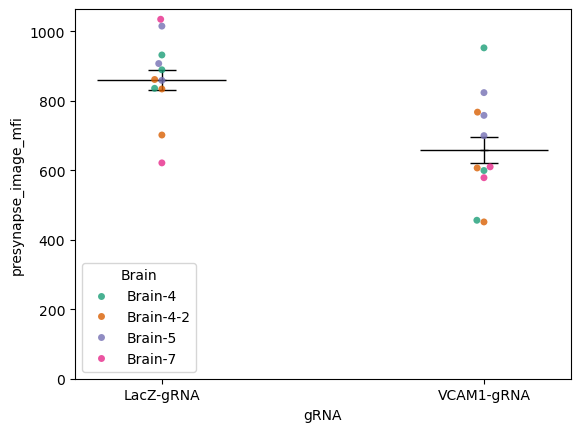

In [9]:
sns.swarmplot(x="gRNA", y="presynapse_image_mfi", hue="Brain", alpha=0.8, palette="Dark2", data=df_filtered)
# line as mean
mean = table.mean()
for i, m in enumerate(mean):
    plt.hlines(m, i - 0.2, i + 0.2, color='black', linewidth=1)

sem = table.sem()
# rest of error bar
plt.errorbar(range(len(mean)), mean, yerr = sem, capsize = 10, color='black', alpha=1,
             linewidth=1, linestyle='', marker='_')
plt.ylim(bottom = 0)

In [7]:
filtered_df_CA3_SL = df[df['hippocampal_layer'].str.contains('CA3 SL')]

In [10]:
# statistics and getting into the right format - CA3 SL
ReplicateAverages = filtered_df_CA3_SL.groupby(["gRNA","Brain"], as_index=False).agg({"presynapse_image_mfi":"mean"})
ReplicateAverages.head(5)
ReplicateAvePivot = ReplicateAverages.pivot_table(columns="gRNA", values="presynapse_image_mfi", index="Brain")
ReplicateAvePivot.head(10)

gRNA,LacZ-gRNA,VCAM1-gRNA
Brain,,
Brain-4,1161.365756,734.770922
Brain-4-2,678.876933,455.993738
Brain-5,1074.041745,740.594560
Brain-7,659.677138,463.068465


In [11]:
statistic, pvalue = scipy.stats.ttest_rel(ReplicateAvePivot["LacZ-gRNA"], ReplicateAvePivot["VCAM1-gRNA"])
print("pvalue:", pvalue, "\n" "& t-statistic:", statistic)
mean = ReplicateAvePivot.mean()
print(mean)
sem = ReplicateAvePivot.sem()
print(sem)

pvalue: 0.011440825772768679 
& t-statistic: 5.566397728654104
gRNA
LacZ-gRNA     893.490393
VCAM1-gRNA    598.606921
dtype: float64
gRNA
LacZ-gRNA     130.729867
VCAM1-gRNA     80.317245
dtype: float64


In [146]:
import numpy as np
from matplotlib.patches import PathPatch

def adjust_box_widths(g, fac):
    """
    Adjust the widths of a seaborn-generated boxplot.
    """

    # iterating through Axes instances
    for ax in g.axes:

        # iterating through axes artists:
        for c in ax.get_children():

            # searching for PathPatches
            if isinstance(c, PathPatch):
                # getting current width of box:
                p = c.get_path()
                verts = p.vertices
                verts_sub = verts[:-1]
                xmin = np.min(verts_sub[:, 0])
                xmax = np.max(verts_sub[:, 0])
                xmid = 0.5*(xmin+xmax)
                xhalf = 0.5*(xmax - xmin)

                # setting new width of box
                xmin_new = xmid-fac*xhalf
                xmax_new = xmid+fac*xhalf
                verts_sub[verts_sub[:, 0] == xmin, 0] = xmin_new
                verts_sub[verts_sub[:, 0] == xmax, 0] = xmax_new

                # setting new width of median line
                for l in ax.lines:
                    if np.all(l.get_xdata() == [xmin, xmax]):
                        l.set_xdata([xmin_new, xmax_new])

In [34]:


def plot_data(df, x, y, extra_y_upper, title, hue = "gRNA", extra_y_lower = 0, ax = None):
    if ax is None:
        fig, ax = plt.subplots()
    p = sns.swarmplot(x=x, y=y, hue = hue,
                    data = df,
                    # jitter = False,
                    dodge = True,
                    marker = "o",
                    alpha = 0.5,
                    ax = ax)
    max_y = df[y].max()
    min_y = df[y].min()

    y_upper_limit = max_y + extra_y_upper
    
    if min_y < 0:
        y_lower_limit = min_y + extra_y_lower
    else:
        y_lower_limit = 0
    
    sns.boxplot(showmeans=True,
            meanline=True,
            meanprops={'color': 'k', 'ls': '-', 'lw': 1.5},
            medianprops={'visible': False},
            whiskerprops={'visible': False},
            zorder=1,
            x=x,
            y=y,
            hue=hue,
            data=df,
            dodge=0.1,
            showfliers=False,
            showbox=False,
            showcaps=False,
            width= 0.8,
            gap = .3,
            legend = False)
    
    p.set_title(title)
    p.set_ylim(y_lower_limit, y_upper_limit)

    return p

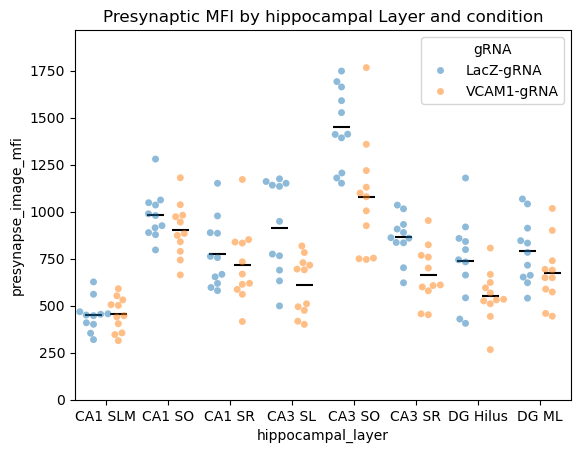

In [35]:
plot_pre_mfi = plot_data(df=df, x="hippocampal_layer", y="presynapse_image_mfi", extra_y_upper=200, title='Presynaptic MFI by hippocampal Layer and condition', extra_y_lower=-0.05)


/Users/cgeyskens/miniconda3/envs/image-analysis/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/cgeyskens/miniconda3/envs/image-analysis/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/cgeyskens/miniconda3/envs/image-analysis/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


(0.0, 1840.5467511530255)

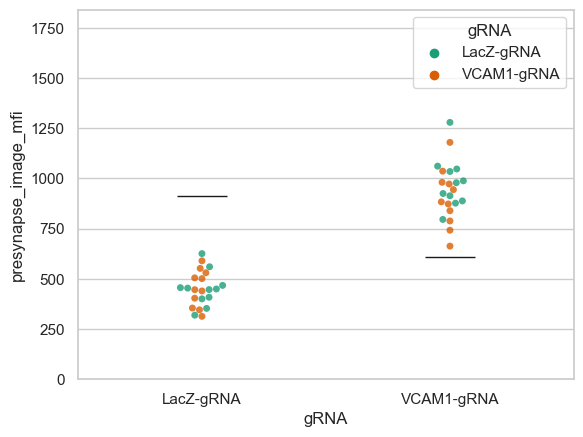

In [125]:
sns.swarmplot(x="hippocampal_layer", y="presynapse_image_mfi", hue="gRNA", alpha=0.8, palette="Dark2", data=df)
# # line as mean
# for i, m in enumerate(mean):
#     plt.hlines(m, i - 0.1, i + 0.1, color='black', linewidth=1)

sns.boxplot(showmeans=True,
            meanline=True,
            meanprops={'color': 'k', 'ls': '-', 'lw': 1},
            medianprops={'visible': False},
            whiskerprops={'visible': False},
            zorder=1,
            x="gRNA",
            y="presynapse_image_mfi",
            data=filtered_df_CA3_SL,
            showfliers=False,
            showbox=False,
            showcaps=False,
            width=0.2)

plt.ylim(bottom = 0)

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap

sns.set(style="whitegrid")
tips = sns.load_dataset("tips")
tips.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


/Users/cgeyskens/miniconda3/envs/image-analysis/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/cgeyskens/miniconda3/envs/image-analysis/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/cgeyskens/miniconda3/envs/image-analysis/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


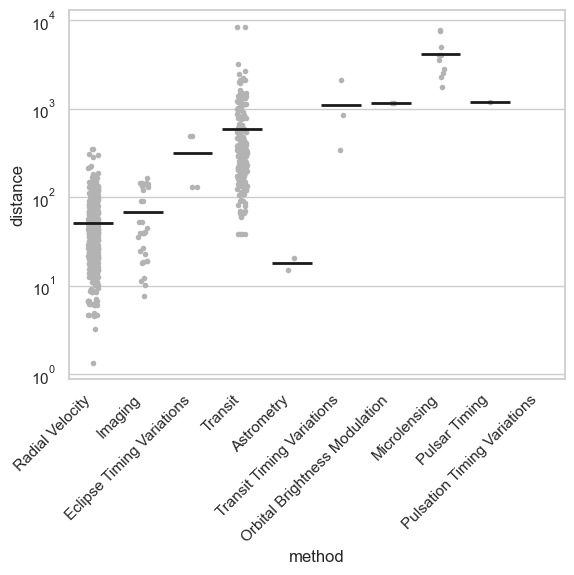

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# load the dataset
planets = sns.load_dataset("planets")

p = sns.stripplot(x="method", y="distance", data=planets, size=4, color=".7")
plt.xticks(rotation=45, ha="right")
p.set(yscale='log')

# plot the mean line
sns.boxplot(showmeans=True,
            meanline=True,
            meanprops={'color': 'k', 'ls': '-', 'lw': 2},
            medianprops={'visible': False},
            whiskerprops={'visible': False},
            zorder=10,
            x="method",
            y="distance",
            data=planets,
            showfliers=False,
            showbox=False,
            showcaps=False,
            ax=p)
plt.show()
